# grid_py Tutorial 1: CairoRenderer Basics

This notebook demonstrates the core grid_py drawing primitives using the **CairoRenderer** backend.

grid_py is a Python port of R's `grid` graphics system — the low-level engine behind ggplot2.

**Key principle**: Layout is expressed through the **Unit system** (`npc`, `cm`, `lines`, `char`, etc.),
not hardcoded pixel values. This ensures plots adapt to different device sizes and font configurations.

In [1]:
import numpy as np
from IPython.display import display, Image

from grid_py import (
    CairoRenderer, Gpar, Unit, Viewport, GridLayout,
    get_state, grid_draw, grid_newpage,
    push_viewport, pop_viewport,
    rect_grob, circle_grob, text_grob, lines_grob,
    points_grob, polygon_grob, segments_grob,
    roundrect_grob, path_grob,
)

def show(renderer):
    """Display a CairoRenderer's output inline."""
    display(Image(data=renderer.to_png_bytes()))

## 1. Basic Shapes

NPC (Normalised Parent Coordinates): `(0,0)` = bottom-left, `(1,1)` = top-right.
Shapes are positioned with `Unit` objects — even plain floats are implicitly NPC.

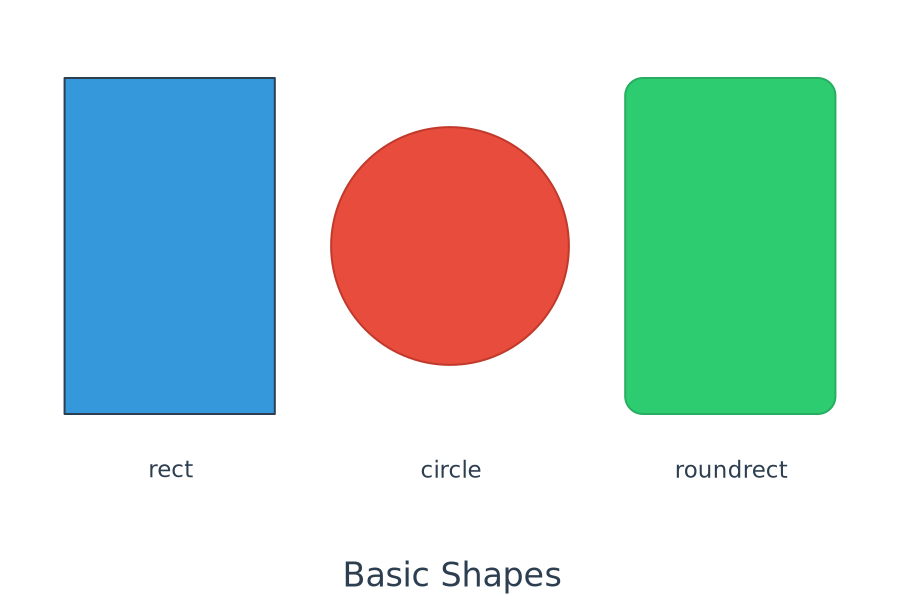

In [2]:
r = CairoRenderer(width=6, height=4, dpi=150, bg='white')
state = get_state()
state.init_device(r)

# Title viewport: 2 lines at the top
title_vp = Viewport(name='title',
    x=Unit(0.5, 'npc'), y=Unit(1, 'npc') - Unit(1, 'lines'),
    width=Unit(1, 'npc'), height=Unit(2, 'lines'))
push_viewport(title_vp, recording=False)
r.push_viewport(title_vp)
grid_draw(text_grob(label='Basic Shapes', x=0.5, y=0.5,
                     gp=Gpar(fontsize=16, fontface='bold', col='#2c3e50')))
pop_viewport(1, recording=False)
r.pop_viewport()

# Content viewport: below title, with 0.5cm margins
content_vp = Viewport(name='content',
    x=Unit(0.5, 'npc'),
    y=Unit(0.5, 'npc') - Unit(1, 'lines'),
    width=Unit(1, 'npc') - Unit(1, 'cm'),
    height=Unit(1, 'npc') - Unit(4, 'lines'))
push_viewport(content_vp, recording=False)
r.push_viewport(content_vp)

# Three shapes using relative positions within the content viewport
grid_draw(rect_grob(x=Unit(1/6, 'npc'), y=0.55, width=0.25, height=0.7,
                     gp=Gpar(fill='#3498db', col='#2c3e50', lwd=2)))
grid_draw(circle_grob(x=Unit(0.5, 'npc'), y=0.55, r=0.18,
                       gp=Gpar(fill='#e74c3c', col='#c0392b', lwd=2)))
grid_draw(roundrect_grob(x=Unit(5/6, 'npc'), y=0.55, width=0.25, height=0.7,
                          r=Unit(0.3, 'cm'),
                          gp=Gpar(fill='#2ecc71', col='#27ae60', lwd=2)))

# Labels: positioned 1.5 lines from bottom
for lbl, xpos in [('rect', 1/6), ('circle', 0.5), ('roundrect', 5/6)]:
    grid_draw(text_grob(label=lbl, x=xpos, y=Unit(1.5, 'lines'),
                         gp=Gpar(fontsize=11, col='#2c3e50')))

pop_viewport(1, recording=False)
r.pop_viewport()

show(r)

## 2. Lines, Points, and Polygons

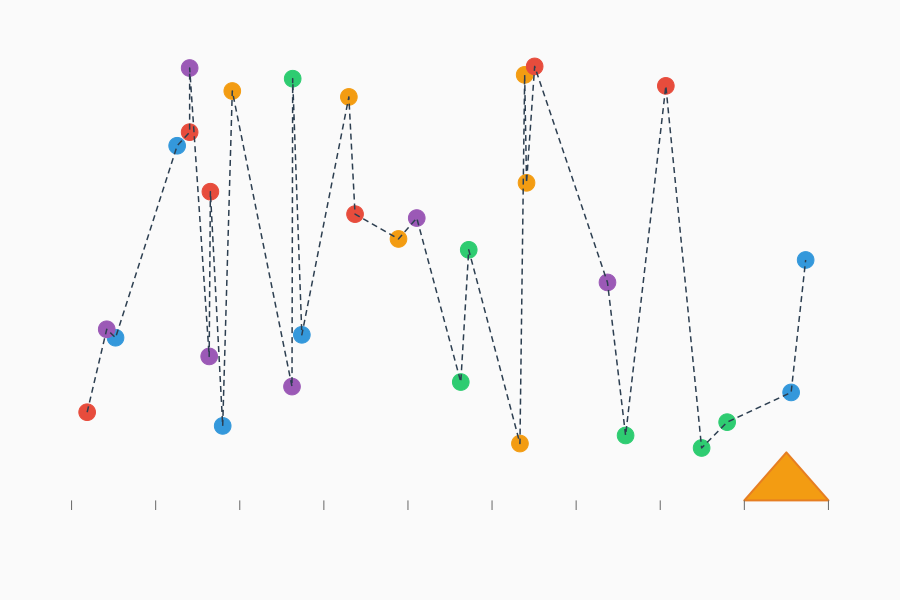

In [3]:
r = CairoRenderer(width=6, height=4, dpi=150, bg='#fafafa')
state.init_device(r)

# Title
title_vp = Viewport(name='title',
    x=Unit(0.5, 'npc'), y=Unit(1, 'npc') - Unit(1, 'lines'),
    width=Unit(1, 'npc'), height=Unit(2, 'lines'))
push_viewport(title_vp, recording=False)
r.push_viewport(title_vp)
grid_draw(text_grob(label='Scatter + Lines + Polygon', x=0.5, y=0.5,
                     gp=Gpar(fontsize=14, fontface='bold')))
pop_viewport(1, recording=False)
r.pop_viewport()

# Plot area
plot_vp = Viewport(name='plot',
    x=Unit(0.5, 'npc'),
    y=Unit(0.5, 'npc') - Unit(1, 'lines'),
    width=Unit(1, 'npc') - Unit(1, 'cm'),
    height=Unit(1, 'npc') - Unit(4, 'lines'))
push_viewport(plot_vp, recording=False)
r.push_viewport(plot_vp)

# Scatter points
np.random.seed(42)
n = 30
x = np.random.rand(n) * 0.9 + 0.05
y = np.random.rand(n) * 0.85 + 0.1
cols = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'] * 6
grid_draw(points_grob(x=x, y=y, pch=19,
                       gp=Gpar(col=cols[:n], fill=cols[:n], fontsize=8)))

# Dashed line through data
order = np.argsort(x)
grid_draw(lines_grob(x=x[order], y=y[order],
                      gp=Gpar(col='#2c3e50', lwd=1.5, lty='dashed')))

# Polygon (triangle) in bottom-right
grid_draw(polygon_grob(x=[0.85, 0.95, 0.9], y=[0.02, 0.02, 0.12],
                        gp=Gpar(fill='#f39c12', col='#e67e22', lwd=2)))

# Bottom tick marks
tick_x = np.linspace(0.05, 0.95, 10)
grid_draw(segments_grob(
    x0=tick_x, y0=np.full(10, 0.0),
    x1=tick_x, y1=np.full(10, 0.02),
    gp=Gpar(col='grey40')))

pop_viewport(1, recording=False)
r.pop_viewport()

show(r)

## 3. Viewports and Layouts

Viewports are the heart of grid — they define nested coordinate systems.
A `GridLayout` divides space into rows and columns using `Unit` widths/heights.

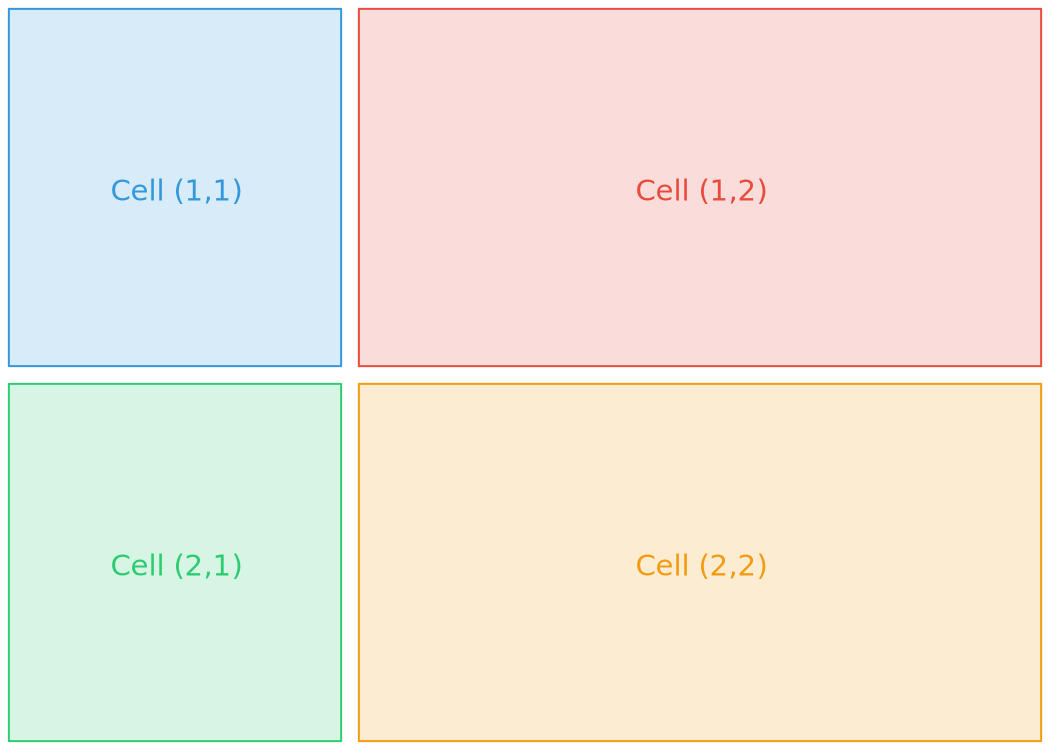

In [4]:
r = CairoRenderer(width=7, height=5, dpi=150, bg='white')
state.init_device(r)

# Title: 2 lines at top
title_vp = Viewport(name='title',
    x=Unit(0.5, 'npc'), y=Unit(1, 'npc') - Unit(1, 'lines'),
    width=Unit(1, 'npc'), height=Unit(2, 'lines'))
push_viewport(title_vp, recording=False)
r.push_viewport(title_vp)
grid_draw(text_grob(label='2x2 Grid Layout (col widths 1:2)', x=0.5, y=0.5,
                     gp=Gpar(fontsize=16, fontface='bold')))
pop_viewport(1, recording=False)
r.pop_viewport()

# Layout area: unit-based margins
layout = GridLayout(
    nrow=2, ncol=2,
    widths=Unit([1, 2], 'null'),     # 2nd column is twice as wide
    heights=Unit([1, 1], 'null'),
)
main_vp = Viewport(name='main',
    x=Unit(0.5, 'npc'),
    y=Unit(0.5, 'npc') - Unit(1, 'lines'),
    width=Unit(1, 'npc') - Unit(1, 'cm'),
    height=Unit(1, 'npc') - Unit(4, 'lines'),
    layout=layout)
push_viewport(main_vp, recording=False)
r.push_viewport(main_vp)

# Draw in each cell
cell_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
cell_labels = ['Cell (1,1)', 'Cell (1,2)', 'Cell (2,1)', 'Cell (2,2)']

for row in [1, 2]:
    for col in [1, 2]:
        idx = (row - 1) * 2 + (col - 1)
        vp = Viewport(name=f'cell_{row}_{col}',
                       layout_pos_row=row, layout_pos_col=col)
        push_viewport(vp, recording=False)
        r.push_viewport(vp)
        grid_draw(rect_grob(x=0.5, y=0.5,
                             width=Unit(1, 'npc') - Unit(0.3, 'cm'),
                             height=Unit(1, 'npc') - Unit(0.3, 'cm'),
                             gp=Gpar(fill=cell_colors[idx] + '30',
                                     col=cell_colors[idx], lwd=2)))
        grid_draw(text_grob(label=cell_labels[idx], x=0.5, y=0.5,
                             gp=Gpar(fontsize=14, col=cell_colors[idx],
                                     fontface='bold')))
        pop_viewport(1, recording=False)
        r.pop_viewport()

pop_viewport(1, recording=False)
r.pop_viewport()

show(r)

## 4. Gradients and Transparency

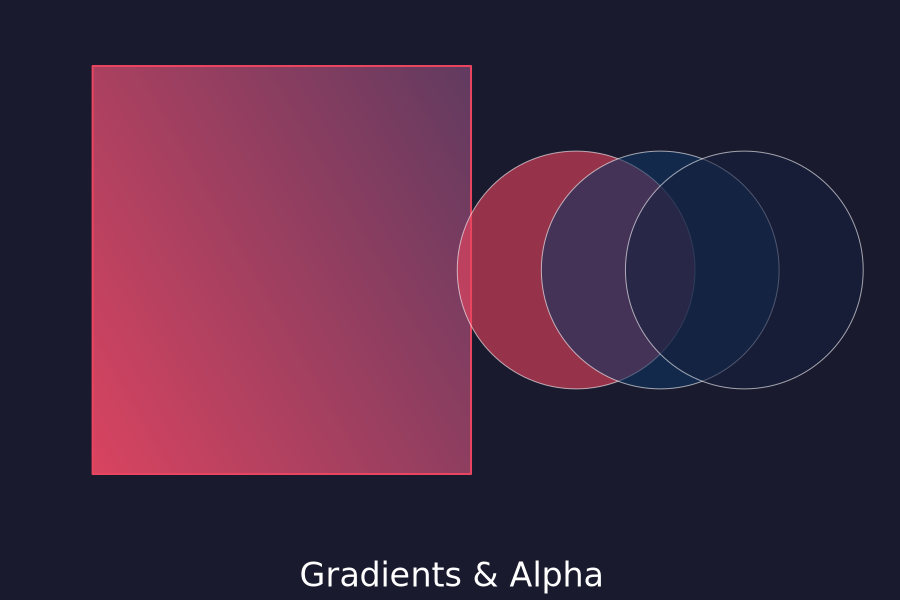

In [5]:
from grid_py._patterns import LinearGradient

r = CairoRenderer(width=6, height=4, dpi=150, bg='#1a1a2e')
state.init_device(r)

# Title
title_vp = Viewport(name='title',
    x=Unit(0.5, 'npc'), y=Unit(1, 'npc') - Unit(1, 'lines'),
    width=Unit(1, 'npc'), height=Unit(2, 'lines'))
push_viewport(title_vp, recording=False)
r.push_viewport(title_vp)
grid_draw(text_grob(label='Gradients & Alpha', x=0.5, y=0.5,
                     gp=Gpar(fontsize=16, fontface='bold', col='white')))
pop_viewport(1, recording=False)
r.pop_viewport()

# Content area
content_vp = Viewport(name='content',
    x=Unit(0.5, 'npc'),
    y=Unit(0.5, 'npc') - Unit(1, 'lines'),
    width=Unit(1, 'npc') - Unit(1, 'cm'),
    height=Unit(1, 'npc') - Unit(4, 'lines'))
push_viewport(content_vp, recording=False)
r.push_viewport(content_vp)

# Linear gradient rectangle
lg = LinearGradient(
    colours=['#e94560', '#0f3460'],
    stops=[0.0, 1.0],
    x1=Unit(0, 'npc'), y1=Unit(0, 'npc'),
    x2=Unit(1, 'npc'), y2=Unit(1, 'npc'),
)
grid_draw(rect_grob(x=0.3, y=0.5, width=0.45, height=0.85,
                     gp=Gpar(fill=lg, col='#e94560', lwd=2)))

# Semi-transparent overlapping circles
for cx, color in [(0.65, '#e94560'), (0.75, '#0f3460'), (0.85, '#16213e')]:
    grid_draw(circle_grob(x=cx, y=0.5, r=0.18,
                           gp=Gpar(fill=color, alpha=0.6, col='white', lwd=1)))

pop_viewport(1, recording=False)
r.pop_viewport()

show(r)

## 5. Output Formats

CairoRenderer supports PNG, PDF, and SVG.

In [6]:
# Save last plot as PNG
r.write_to_png('output_demo.png')
print('Saved output_demo.png')

# PDF
r_pdf = CairoRenderer(width=6, height=4, dpi=72,
                        surface_type='pdf', filename='output_demo.pdf')
r_pdf.draw_rect(0.5, 0.5, 0.8, 0.6, gp=Gpar(fill='#3498db', col='black'))
r_pdf.draw_text(0.5, 0.5, 'PDF Output', gp=Gpar(fontsize=20, col='white'))
r_pdf.finish()
print('Saved output_demo.pdf')

# SVG
r_svg = CairoRenderer(width=6, height=4, dpi=72,
                        surface_type='svg', filename='output_demo.svg')
r_svg.draw_circle(0.5, 0.5, 0.3, gp=Gpar(fill='#e74c3c'))
r_svg.draw_text(0.5, 0.5, 'SVG Output', gp=Gpar(fontsize=20, col='white'))
r_svg.finish()
print('Saved output_demo.svg')

Saved output_demo.png
Saved output_demo.pdf
Saved output_demo.svg
